In [1]:
import threading
import time

SALDO_AWAL = 1_000_000
JUMLAH_THREAD = 10
OPERASI_PER_THREAD = 1_000  # Disesuaikan agar simulasi berjalan cepat

# ============ (a) TANPA LOCK (RACE CONDITION TERLIHAT) ============
saldo = SALDO_AWAL

def tarik_setor():
    """Memaksa race condition dengan memisah pembacaan dan penulisan saldo."""
    global saldo
    for _ in range(OPERASI_PER_THREAD):
        # Operasi Tarik: Baca -> Tunda -> Tulis
        temp = saldo
        time.sleep(0.00001)  # Memaksa Python memindahkan eksekusi ke thread lain
        saldo = temp - 1

        # Operasi Setor: Baca -> Tunda -> Tulis
        temp = saldo
        time.sleep(0.00001)
        saldo = temp + 1

print("VERSI TANPA LOCK (Memicu Race Condition)")
for percobaan in range(5):
    saldo = SALDO_AWAL
    threads = [threading.Thread(target=tarik_setor) for _ in range(JUMLAH_THREAD)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    waktu = time.perf_counter() - start
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo:,} "
          f"({'TETAP' if saldo == SALDO_AWAL else 'BERUBAH!'}), "
          f"waktu = {waktu:.2f} detik")

# ============ (b) DENGAN threading.Lock() ============
lock = threading.Lock()

def tarik_setor_locked():
    """Aman dari race condition karena dilindungi oleh lock."""
    global saldo
    for _ in range(OPERASI_PER_THREAD):
        with lock:  # Hanya 1 thread yang bisa mengeksekusi blok ini dalam satu waktu
            temp = saldo
            time.sleep(0.00001)
            saldo = temp - 1

            temp = saldo
            time.sleep(0.00001)
            saldo = temp + 1

print("\nVERSI DENGAN LOCK (Data Konsisten)")
for percobaan in range(5):
    saldo = SALDO_AWAL
    threads = [threading.Thread(target=tarik_setor_locked) for _ in range(JUMLAH_THREAD)]
    start = time.perf_counter()
    for t in threads: t.start()
    for t in threads: t.join()
    waktu = time.perf_counter() - start
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo:,} "
          f"({'TETAP' if saldo == SALDO_AWAL else 'BERUBAH!'}), "
          f"waktu = {waktu:.2f} detik")

VERSI TANPA LOCK (Memicu Race Condition)
Percobaan 1: saldo akhir = 1,000,000 (TETAP), waktu = 1.23 detik
Percobaan 2: saldo akhir = 999,997 (BERUBAH!), waktu = 1.20 detik
Percobaan 3: saldo akhir = 999,998 (BERUBAH!), waktu = 1.41 detik
Percobaan 4: saldo akhir = 1,000,000 (TETAP), waktu = 1.60 detik
Percobaan 5: saldo akhir = 999,999 (BERUBAH!), waktu = 2.49 detik

VERSI DENGAN LOCK (Data Konsisten)
Percobaan 1: saldo akhir = 1,000,000 (TETAP), waktu = 13.95 detik
Percobaan 2: saldo akhir = 1,000,000 (TETAP), waktu = 14.84 detik
Percobaan 3: saldo akhir = 1,000,000 (TETAP), waktu = 15.50 detik
Percobaan 4: saldo akhir = 1,000,000 (TETAP), waktu = 14.14 detik
Percobaan 5: saldo akhir = 1,000,000 (TETAP), waktu = 14.19 detik


In [2]:
import queue
import threading
import time

# Inisialisasi antrean (queue)
q = queue.Queue()


def producer():
    for i in range(1, 10):
        item = f"Data-{i}"
        q.put(item)
        print(f"[Producer] Mengirim: {item}")
        time.sleep(0.1)

    # Mengirim sinyal None sebanyak jumlah consumer (3 consumer)
    # agar setiap consumer menerima satu sinyal untuk berhenti (Poison Pill Pattern)
    for _ in range(3):
        q.put(None)

    print("[Producer] Selesai memproduksi data dan mengirim sinyal berhenti.")


def consumer(id_consumer):
    while True:
        item = q.get()

        # Cek sinyal berhenti (Poison Pill)
        if item is None:
            q.task_done()
            print(f"  [Consumer-{id_consumer}] Menerima sinyal berhenti. Keluar.")
            break

        # Proses data
        print(f"  [Consumer-{id_consumer}] Memproses: {item}")
        time.sleep(0.2)
        q.task_done()


# Membuat dan menjalankan thread Producer
t_prod = threading.Thread(target=producer)
t_prod.start()

# Membuat dan menjalankan 3 thread Consumer
consumers = []
for i in range(1, 4):
    t_cons = threading.Thread(target=consumer, args=(i,))
    t_cons.start()
    consumers.append(t_cons)

# Menunggu producer dan seluruh consumer selesai
t_prod.join()
for t_cons in consumers:
    t_cons.join()

print("Seluruh proses Producer-Consumer selesai.")

[Producer] Mengirim: Data-1
  [Consumer-1] Memproses: Data-1
[Producer] Mengirim: Data-2
  [Consumer-2] Memproses: Data-2
[Producer] Mengirim: Data-3
  [Consumer-3] Memproses: Data-3
[Producer] Mengirim: Data-4  [Consumer-1] Memproses: Data-4

[Producer] Mengirim: Data-5
  [Consumer-2] Memproses: Data-5
[Producer] Mengirim: Data-6
  [Consumer-3] Memproses: Data-6
[Producer] Mengirim: Data-7  [Consumer-1] Memproses: Data-7

[Producer] Mengirim: Data-8
  [Consumer-2] Memproses: Data-8
[Producer] Mengirim: Data-9
  [Consumer-3] Memproses: Data-9
[Producer] Selesai memproduksi data dan mengirim sinyal berhenti.  [Consumer-2] Menerima sinyal berhenti. Keluar.
  [Consumer-1] Menerima sinyal berhenti. Keluar.

  [Consumer-3] Menerima sinyal berhenti. Keluar.
Seluruh proses Producer-Consumer selesai.


=== MEMULAI EKSPERIMEN THREADPOOLEXECUTOR ===
max_workers =  2 | Waktu Eksekusi: 13.27 detik
max_workers =  4 | Waktu Eksekusi: 6.81 detik
max_workers =  8 | Waktu Eksekusi: 3.59 detik
max_workers = 16 | Waktu Eksekusi: 1.98 detik


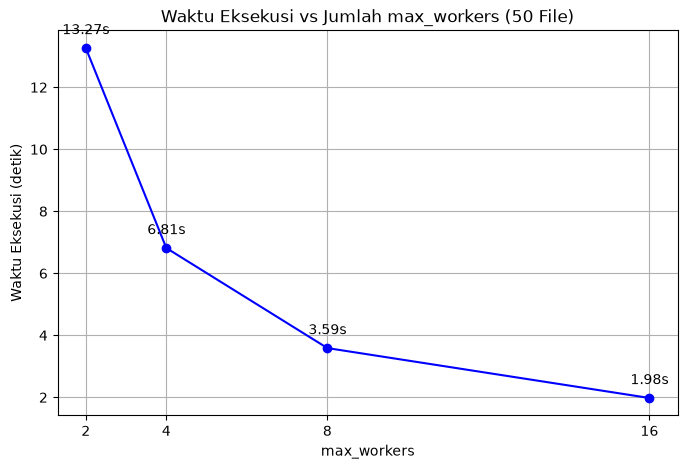

In [4]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import matplotlib.pyplot as plt
import random
import time

# --- 1. Persiapan Data (50 File) ---
random.seed(42)  # Seed dipertahankan agar hasil eksperimen konsisten
JUMLAH_FILE = 50

daftar_file = [f"file_{i}.dat" for i in range(JUMLAH_FILE)]
latensi_simulasi = {
    f: random.uniform(0.3, 0.8) for f in daftar_file
}  # Simulasi latensi seperti di bagian 6.1


def download_file(nama_file):
    durasi = latensi_simulasi[nama_file]
    time.sleep(durasi)  # Menyimulasikan I/O-bound
    ukuran_kb = round(durasi * 1000)
    return f"{nama_file} ({ukuran_kb} KB)"


# --- 2. Eksperimen ThreadPoolExecutor dengan Variasi max_workers ---
worker_list = [2, 4, 8, 16]
waktu_eksekusi = []

print("=== MEMULAI EKSPERIMEN THREADPOOLEXECUTOR ===")
for workers in worker_list:
    start = time.perf_counter()

    with ThreadPoolExecutor(max_workers=workers) as executor:
        futures = [executor.submit(download_file, f) for f in daftar_file]
        # Menunggu seluruh task selesai
        for future in as_completed(futures):
            _ = future.result()

    waktu_total = time.perf_counter() - start
    waktu_eksekusi.append(waktu_total)
    print(f"max_workers = {workers:2d} | Waktu Eksekusi: {waktu_total:.2f} detik")

# --- 3. Plot Hasil Eksperimen ---
plt.figure(figsize=(8, 5))
plt.plot(worker_list, waktu_eksekusi, marker="o", color="b", linestyle="-")
plt.title("Waktu Eksekusi vs Jumlah max_workers (50 File)")
plt.xlabel("max_workers")
plt.ylabel("Waktu Eksekusi (detik)")
plt.xticks(worker_list)
plt.grid(True)

# Menampilkan nilai waktu di setiap titik plot
for i, txt in enumerate(waktu_eksekusi):
    plt.annotate(
        f"{txt:.2f}s",
        (worker_list[i], waktu_eksekusi[i]),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
    )

plt.show()


#1. Apakah menambah max_workers terus-menerus selalu mempercepat proses?   
#Tidak. Menambah max_workers hanya akan mempercepat proses secara signifikan hingga batas titik tertentu. 
#Setelah titik tersebut tercapai, peningkatan jumlah thread tidak lagi memberikan penurunan waktu eksekusi yang signifikan (mengalami diminishing returns) atau bahkan bisa sedikit melambat.

#Mengapa terjadi titik jenuh (saturation point)?   Thread Overhead & Context Switching: Membuat dan mengelola thread dalam jumlah yang terlalu banyak membutuhkan konsumsi memori serta overhead manajemen CPU (context switching) yang lebih besar.Keterbatasan Resource/Batas Paralelisme: Pada tugas I/O-bound simulasi ini, batas kecepatan eksekusi akhirnya ditentukan oleh ketersediaan core CPU yang menjadwalkan thread serta batasan kapasitas bandwidth atau antrean sistem operasi.GIL (Global Interpreter Lock) di Python: Meskipun tugas I/O-bound melepas GIL saat time.sleep(), eksekusi kode interpreter Python di luar pemanggilan I/O tetap dikendalikan oleh GIL secara bergantian. 